In [2]:
import pandas as pd
import numpy as np
import os
import sys  
import argparse
import logging
import time
import json
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler,StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pipe = make_pipeline(MinMaxScaler(), LogisticRegression())
print("Pipeline steps:")
print(pipe.steps)   

Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('logisticregression', LogisticRegression())]


In [4]:
df = pd.read_csv('pima-indians-diabetes.csv')
df.head()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Seperating features and target variable
X = df.drop('class', axis=1)
Y = df['class']

In [7]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.30, random_state=1, stratify=Y)
# Fit the pipeline to the training data

In [8]:

pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression())])
pipeline.fit(Xtrain, Ytrain)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [9]:
print("Pipeline steps:")
print(pipeline.steps)   

Pipeline steps:
[('scaler', StandardScaler()), ('classifier', LogisticRegression())]


In [12]:
pipeline.score(Xtrain, Ytrain)

0.7839851024208566

In [13]:
pipeline.score(Xtest, Ytest)

0.7619047619047619

In [14]:
pipe = make_pipeline(StandardScaler(), LogisticRegression())
print("Pipeline steps:")
print(pipe.steps)

Pipeline steps:
[('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression())]


In [15]:
pipe.fit(Xtrain, Ytrain)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [16]:
pipe.score(Xtrain, Ytrain)

0.7839851024208566

In [17]:
pipe.score(Xtest, Ytest)

0.7619047619047619

In [22]:
from PIL import Image
import pytesseract

# Specify the path to the image
image_path = "D:/Piyush/Pictures/Advanced Machine Learning-HandsOnQuiz.JPG"

# Open the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_output = pytesseract.image_to_string(image)

# Print the OCR output
print(ocr_output)

Problem Statement:

Cardiac arrest is an abrupt loss of heart functioning. The condition generally results from a problem with the heart’s electrical system that disturbs the heart's pumping action. This malfunction can cause a
life-threatening condition. Due to cardiac arrest, millions of people die every year. Hence, it would be a lifesaver if we can build a system that is capable of predicting heart failure.

Certain medical parameters help in predicting if a person is at risk of getting a cardiac arrest. Such features are stored in ‘Cardiac.csv’.

Attribute Information-

1. Gender: This feature represents the gender of a person; O- Other, 1- Male, 2- Female.
2. Chain_smoker: This feature represents if the person is a chain smoker or not
3. Consumes_other_tobacco_products: This feature represents if the person consumes other tobacco products.
4. HighBP: This feature represents if the person has high blood pressure or not.
5. Obese: This feature represents if the person is obese or n

In [32]:
cardiac_df = pd.read_csv('cardiac.csv')
cardiac_df.head()

,Gender,Chain_smoker,Consumes_other_tobacco_products,HighBP,Obese,Diabetes,Metabolic_syndrome,Use_of_stimulant_drugs,Family_history,History_of_preeclampsia,CABG_history,Respiratory_illness,UnderRisk
0,Male,1,1,0,1,0,0,0,1,0,0,0,no
1,Male,0,1,0,1,0,0,0,1,0,0,0,no
2,Male,0,1,0,1,0,0,0,1,0,0,0,no
3,Male,0,1,0,1,0,0,0,1,0,0,0,no
4,Male,0,0,0,0,0,1,1,0,0,0,0,no


In [33]:
class_distribution = cardiac_df['UnderRisk'].value_counts(normalize=True) * 100
print("Class Distribution (%):")
print(class_distribution)

Class Distribution (%):
UnderRisk
no     78.627672
yes    21.372328
Name: proportion, dtype: float64


In [35]:
# Encode target variable (Replace yes with 1 and no with 0)
# Split data into temp and test in the 80:20 ration. Use the parameter stratify while spliting data
# Split the temp set into train and validation in the 75:25 ratio. Use the parameter 'stratify' while splitting the data
# Create dummies for X_Train, X_Val, and X_test. Use drop_first = True while creating dummies.

# Encode target variable
cardiac_df['UnderRisk'] = cardiac_df['UnderRisk'].replace({'yes': 1, 'no': 0})

# Split data into temp and test sets (80:20 ratio)
temp, X_test, temp_target, Y_test = train_test_split(
    cardiac_df.drop('UnderRisk', axis=1),
    cardiac_df['UnderRisk'],
    test_size=0.2,
    random_state=1,
    stratify=cardiac_df['UnderRisk']
)

# Split temp set into train and validation sets (75:25 ratio)
X_train, X_val, Y_train, Y_val = train_test_split(
    temp,
    temp_target,
    test_size=0.25,
    random_state=1,
    stratify=temp_target
)

# Create dummies for X_train, X_val, and X_test
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [36]:
print(f"Rows and columns in train set: {X_train.shape}")

Rows and columns in train set: (533, 13)


To predict whether a person will have cardiac arrest or not based on medical background, whihc is most appropriate metric of evaluation for prediction

The most appropriate metric for evaluating the prediction of cardiac arrest depends on the class distribution and the problem's context. Since cardiac arrest prediction is a critical medical problem, **recall (sensitivity)** is often the most appropriate metric. 

### Why Recall?
- Recall measures the proportion of actual positive cases (people at risk of cardiac arrest) that are correctly identified by the model.
- In medical scenarios, missing a positive case (false negative) can have severe consequences, as it means failing to identify someone at risk.

### Additional Considerations:
- If the dataset is imbalanced (e.g., far more people without risk than with risk), metrics like **F1-score** (harmonic mean of precision and recall) or **ROC-AUC** can also be useful.
- Precision might be important if false positives (incorrectly predicting risk) lead to unnecessary interventions or costs.

In summary, **recall** or **F1-score** is typically the most appropriate metric for this problem.

In [37]:
# Train a Logistic Regression model
logistic_model = LogisticRegression(random_state=1)
logistic_model.fit(X_train, Y_train)

# Check the performance of the model on the train set
train_score = logistic_model.score(X_train, Y_train)
print(f"Performance of the Logistic Regression model on the train set: {train_score}")

Performance of the Logistic Regression model on the train set: 0.7879924953095685


In [42]:
from sklearn.metrics import classification_report

# Generate predictions on the validation set
Y_train_pred = logistic_model.predict(X_train)

# Print the classification report
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.79      0.99      0.88       419
           1       0.57      0.04      0.07       114

    accuracy                           0.79       533
   macro avg       0.68      0.51      0.47       533
weighted avg       0.74      0.79      0.71       533



In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize bagging with the given parameters
bagging = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)

# Apply SMOTE to the training data
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

# Print the shape of the oversampled data
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Shape of Y_train after SMOTE: {Y_train_smote.shape}")

Shape of X_train after SMOTE: (838, 13)
Shape of Y_train after SMOTE: (838,)


In [43]:
from sklearn.metrics import classification_report

# Generate predictions on the validation set
Y_train_smote_pred = logistic_model.predict(X_train_smote)

# Print the classification report
print(classification_report(Y_train_smote, Y_train_smote_pred))

              precision    recall  f1-score   support

           0       0.50      0.99      0.67       419
           1       0.75      0.02      0.04       419

    accuracy                           0.51       838
   macro avg       0.63      0.51      0.36       838
weighted avg       0.63      0.51      0.36       838



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions on the validation set for the original data
Y_val_pred_original = logistic_model.predict(X_val)

# Metrics for the original data
accuracy_original = accuracy_score(Y_val, Y_val_pred_original)
precision_original = precision_score(Y_val, Y_val_pred_original)
recall_original = recall_score(Y_val, Y_val_pred_original)

# Metrics for the oversampled data
bagging = accuracy_score(Y_train_smote, Y_train_smote_pred)
precision_smote = precision_score(Y_train_smote, Y_train_smote_pred)
recall_smote = recall_score(Y_train_smote, Y_train_smote_pred)

# Print the results
print("Metrics for Original Data:")
print(f"Accuracy: {accuracy_original:.4f}")
print(f"Precision: {precision_original:.4f}")
print(f"Recall: {recall_original:.4f}")

print("\nMetrics for Oversampled Data (SMOTE):")
print(f"Accuracy: {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall: {recall_smote:.4f}")

# Conclusion
if recall_smote > recall_original:
    print("\nConclusion: The model trained on oversampled data using SMOTE has improved recall, which is crucial for identifying positive cases in imbalanced datasets.")
else:
    print("\nConclusion: The model trained on original data has better recall, but oversampling may still be beneficial depending on the problem context.")

Metrics for Original Data:
Accuracy: 0.7697
Precision: 0.2000
Recall: 0.0263

Metrics for Oversampled Data (SMOTE):
Accuracy: 0.5072
Precision: 0.7500
Recall: 0.0215

Conclusion: The model trained on original data has better recall, but oversampling may still be beneficial depending on the problem context.


In [49]:
# Train bagging classifier on the oversampled data with default parameters and random_state=1 and check model performance on the validation set.
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report

# Initialize the Bagging Classifier with random_state=1
bagging_model = BaggingClassifier(random_state=1)

# Train the model on the oversampled data
bagging_model.fit(X_train, Y_train)

# Generate predictions on the validation set
Y_val_pred_bagging = bagging_model.predict(X_val)

# Evaluate the model's performance
print("Classification Report for Bagging Classifier on Validation Set:")
print(classification_report(Y_val, Y_val_pred_bagging))

Classification Report for Bagging Classifier on Validation Set:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       140
           1       0.29      0.13      0.18        38

    accuracy                           0.75       178
   macro avg       0.54      0.52      0.52       178
weighted avg       0.69      0.75      0.71       178



In [50]:

# Metrics for the oversampled data
accuracy_bagging = accuracy_score(Y_val, Y_val_pred_bagging)
precision_bagging = precision_score(Y_val, Y_val_pred_bagging)
recall_bagging = recall_score(Y_val, Y_val_pred_bagging)

# Print the results
print("Metrics for Bagging Data:")
print(f"Accuracy: {accuracy_original:.4f}")
print(f"Precision: {precision_original:.4f}")
print(f"Recall: {recall_original:.4f}")

Metrics for Bagging Data:
Accuracy: 0.7697
Precision: 0.2000
Recall: 0.0263


In [ ]:
# Train a random forest classfier with the original training set using default parameters and random_state=1 and assess the model performance on the training set.
# Identify the correct range of a number of cases that are correctly predicted as 'yes' by the random forest classifier.
# Train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=1)
rf_model.fit(X_train, Y_train)

# Generate predictions on the training set
Y_train_pred_rf = rf_model.predict(X_train)

# Count the number of cases correctly predicted as 'yes'
correct_yes_predictions = sum((Y_train == 1) & (Y_train_pred_rf == 1))

print(f"Number of cases correctly predicted as 'yes': {correct_yes_predictions}")

Number of cases correctly predicted as 'yes': 20


In [52]:
# Specify the path to the image
image_path = "D:/Piyush/Pictures/Advanced Machine Learning-HandsOnQuiz2.JPG"

# Open the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_output = pytesseract.image_to_string(image)

# Print the OCR output
print(ocr_output)

One model might not give the desired outcome, we can try different models and compare their performances. Let's try different models.
Train the models as per the following instructions.

¢ Train Bagging classifier using BaggingClassifier(random_state=1)

¢ Train Random forest classifier using RandomForestClassifier(random_state=1)

¢ Train Logistic regression using LogisticRegression(random_state=1)

¢ Train Decision trees using DecisionTreeClassifier(random_state=1)

¢ Loop through all the above models to get the mean cross-validated scores. Use the following code for the CV results on over sampled
data -

scoring = "recall"
kfold = StratifiedKFold(
n_splits=5, shuffle=True, random_state=1
) # Setting number of splits equal to 5
cv_result = cross_val_score(
estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
)
Which of the following statements are true about the cross-validated recall scores on the oversampled data?
A. The average cross-validated recall score fo

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Define the models
models = {
    "BaggingClassifier": BaggingClassifier(random_state=1),
    "RandomForestClassifier": RandomForestClassifier(random_state=1),
    "LogisticRegression": LogisticRegression(random_state=1),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=1)
}

# Define cross-validation strategy
scoring = "recall"
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Perform cross-validation for each model
cv_results = {}
for model_name, model in models.items():
    cv_result = cross_val_score(estimator=model, X=X_train_smote, y=Y_train_smote, scoring=scoring, cv=kfold)
    cv_results[model_name] = cv_result.mean()
    print(f"{model_name}: Mean CV Recall Score = {cv_result.mean():.4f}")

# Analyze the results
print("\nCross-validated recall scores on oversampled data:")
for model_name, score in cv_results.items():
    print(f"{model_name}: {score:.4f}")

BaggingClassifier: Mean CV Recall Score = 0.7684
RandomForestClassifier: Mean CV Recall Score = 0.7709
LogisticRegression: Mean CV Recall Score = 0.7613
DecisionTreeClassifier: Mean CV Recall Score = 0.7684

Cross-validated recall scores on oversampled data:
BaggingClassifier: 0.7684
RandomForestClassifier: 0.7709
LogisticRegression: 0.7613
DecisionTreeClassifier: 0.7684


In [54]:
# Specify the path to the image
image_path = "D:/Piyush/Pictures/Advanced Machine Learning-HandsOnQuiz-3.JPG"

# Open the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_output = pytesseract.image_to_string(image)

# Print the OCR output
print(ocr_output)

Building the model with default parameters might not give a satisfactory outcome. Let's try to identify the best combination of the
hyperparameters.

Train an AdaBoost classifier using the oversampled data and tune the model using random search.
Use the following code to define the parameters -
param_grid = {
"n_estimators": np.arange(10, 110, 10),
“learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
"base_estimator": [
DecisionTreeClassifier(max_depth=1, random_state=1),
DecisionTreeClassifier(max_depth=2, random_state=1),

DecisionTreeClassifier(max_depth=3, random_state=1),

}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)
# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
estimator=model,
param_distributions=param_grid,
n_jobs=-1,
n_iter=50,
scoring=scorer,
cv=5,

random_state=1,



In [57]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics

# Define the parameter grid
# note base_estimator has been deprecated in the latest version of sklearn.
# use estimator instead of base_estimator
param_grid = {
    "n_estimators": np.arange(10, 110, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Define the scoring metric
scorer = metrics.make_scorer(metrics.recall_score)

# Initialize the AdaBoost classifier
adaboost_model = AdaBoostClassifier(random_state=1)

# Perform RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=adaboost_model,
    param_distributions=param_grid,
    n_jobs=-1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1
)

# Fit the RandomizedSearchCV to the oversampled data
randomized_cv.fit(X_train_smote, Y_train_smote)

# Print the best parameters and the best score
print("Best Parameters:", randomized_cv.best_params_)
print("Best Recall Score:", randomized_cv.best_score_)

Best Parameters: {'n_estimators': 70, 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)}
Best Recall Score: 0.9642857142857142


d:\Dev\Tools\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [ ]:
# Train Adaboos classifier with undersampled and oversampled data. 
# Asses the model performance for Adaboost with oversampled data on the oversampled train data and for Adaboost with undersampled data on undersampled train data.
# Print performance comparision of both
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler

# Initialize AdaBoost classifier
adaboost_oversampled = AdaBoostClassifier(random_state=1)
adaboost_undersampled = AdaBoostClassifier(random_state=1)

# Train AdaBoost with oversampled data
adaboost_oversampled.fit(X_train_smote, Y_train_smote)

# Assess performance on oversampled train data
Y_train_smote_pred = adaboost_oversampled.predict(X_train_smote)
print("Performance of AdaBoost with Oversampled Data:")
print(classification_report(Y_train_smote, Y_train_smote_pred))

# Undersample the data
undersampler = RandomUnderSampler(random_state=1)
X_train_under, Y_train_under = undersampler.fit_resample(X_train, Y_train)

# Train AdaBoost with undersampled data
adaboost_undersampled.fit(X_train_under, Y_train_under)

# Assess performance on undersampled train data
Y_train_under_pred = adaboost_undersampled.predict(X_train_under)
print("\nPerformance of AdaBoost with Undersampled Data:")
print(classification_report(Y_train_under, Y_train_under_pred))

# Performance comparison
print("\nPerformance Comparison:")
print("AdaBoost with Oversampled Data:")
print(f"Accuracy: {adaboost_oversampled.score(X_train_smote, Y_train_smote):.4f}")
print("AdaBoost with Undersampled Data:")
print(f"Accuracy: {adaboost_undersampled.score(X_train_under, Y_train_under):.4f}")

Performance of AdaBoost with Oversampled Data:
              precision    recall  f1-score   support

           0       0.71      0.55      0.62       419
           1       0.64      0.78      0.70       419

    accuracy                           0.67       838
   macro avg       0.67      0.67      0.66       838
weighted avg       0.67      0.67      0.66       838


Performance of AdaBoost with Undersampled Data:
              precision    recall  f1-score   support

           0       0.78      0.57      0.66       114
           1       0.66      0.84      0.74       114

    accuracy                           0.71       228
   macro avg       0.72      0.71      0.70       228
weighted avg       0.72      0.71      0.70       228


Performance Comparison:
AdaBoost with Oversampled Data:
Accuracy: 0.6659
AdaBoost with Undersampled Data:
Accuracy: 0.7061


d:\Dev\Tools\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
d:\Dev\Tools\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


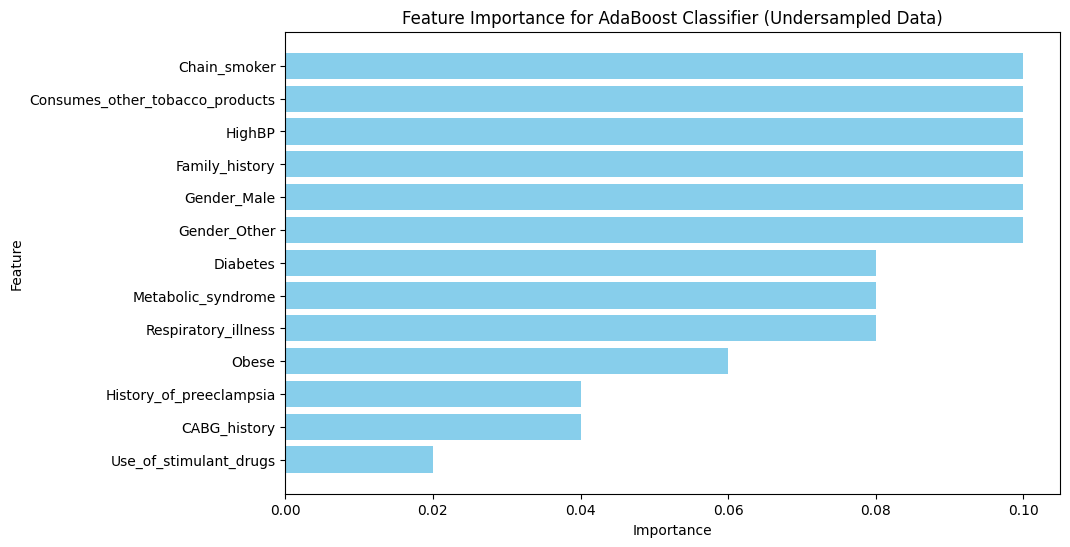

Most Important Features:
                            Feature  Importance
0                      Chain_smoker        0.10
1   Consumes_other_tobacco_products        0.10
2                            HighBP        0.10
7                    Family_history        0.10
11                      Gender_Male        0.10
12                     Gender_Other        0.10
4                          Diabetes        0.08
5                Metabolic_syndrome        0.08
10              Respiratory_illness        0.08
3                             Obese        0.06
8           History_of_preeclampsia        0.04
9                      CABG_history        0.04
6            Use_of_stimulant_drugs        0.02


In [59]:
import pandas as pd

import matplotlib.pyplot as plt

# Extract feature importances
feature_importances = adaboost_undersampled.feature_importances_

# Create a DataFrame for better visualization
features = X_train_under.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for AdaBoost Classifier (Undersampled Data)')
plt.gca().invert_yaxis()
plt.show()

# List the most important features
print("Most Important Features:")
print(importance_df)